# MADS — Threat Detection Random Forest Classifier

This notebook builds a Random Forest classifier to detect malicious activity in a cybersecurity event log dataset.

## Objective
Classify each event as **malicious** or **benign** based on five numerical features (`feature_1` to `feature_5`) extracted from machine activity logs.

## Dataset
- **Source:** `mads_synthetic_dataset_2.csv`
- **Features:** `feature_1`, `feature_2`, `feature_3`, `feature_4`, `feature_5`
- **Label:** `malicious` / `benign`

## Approach
| Step | Description |
|---|---|
| **Data Preparation** | Feature extraction, label encoding, 70/30 stratified train/test split (seed=42), StandardScaler normalisation |
| **Model** | Random Forest with 100 estimators and Gini impurity criterion |
| **Evaluation** | Accuracy, precision, recall, and F1-score on the held-out test set |
| **Feature Importance** | Bar chart of each feature's mean impurity decrease across all trees |
| **Cross-Validation** | 5-fold stratified CV to produce a robust performance estimate (mean ± std accuracy) |

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [5]:
df = pd.read_csv("../datasets/mads_synthetic_dataset_3.csv")
df.head()

,event_id,timestamp,machine,event_type,feature_1,feature_2,feature_3,feature_4,feature_5,ip_address,user_id,process,label
0,EVT-00001,2025-04-13 12:00:00.000000,machine1,execution_suspicious_process,0.6089,0.4587,1.0347,0.7039,0.6019,192.168.1.75,U1017,netstat.exe,malicious
1,EVT-00002,2025-04-13 12:01:01.563700,machine1,lateral_movement,0.1973,1.0347,1.0673,0.1014,0.7431,192.168.1.125,U1008,msiexec.exe,malicious
2,EVT-00003,2025-04-13 12:02:13.269421,machine1,normal_activity,0.4294,0.6387,0.7711,0.5158,0.6117,192.168.1.25,U1017,msiexec.exe,benign
3,EVT-00004,2025-04-13 12:02:47.705168,machine1,phishing_credential_stealer,0.7158,0.9808,1.1189,0.8179,0.6464,192.168.1.65,U1009,whoami.exe,malicious
4,EVT-00005,2025-04-13 12:03:23.701545,machine1,normal_activity,-0.0396,0.3416,0.9948,0.5987,0.8392,192.168.1.55,U1008,msiexec.exe,benign


## Data Preparation

In [6]:
feature_cols = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']

X = df[feature_cols].values.astype(np.float32)
y = (df['label'] == 'malicious').astype(np.float32).values  # 1 = malicious, 0 = benign

# 70/30 stratified split — same seed as the other notebooks
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Fit scaler on training set only to prevent data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples")

for split_name, y_split in [("y_train", y_train), ("y_test", y_test)]:
    benign    = (y_split == 0).sum()
    malicious = (y_split == 1).sum()
    total     = len(y_split)
    print(f"{split_name}  —  benign: {benign} ({benign/total:.1%})  |  malicious: {malicious} ({malicious/total:.1%})  |  total: {total}")

Train: 7000 samples | Test: 3000 samples
y_train  —  benign: 2363 (33.8%)  |  malicious: 4637 (66.2%)  |  total: 7000
y_test  —  benign: 1013 (33.8%)  |  malicious: 1987 (66.2%)  |  total: 3000


## Random Forest Model

In [7]:
model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,      # trees grow until all leaves are pure (or min_samples constraints)
    random_state=42,
    n_jobs=-1            # use all available CPU cores
)
model.fit(X_train, y_train)

print("Random Forest fitted.")
print(f"Number of trees : {model.n_estimators}")
print(f"Number of features used per split (sqrt): {model.max_features}")

Random Forest fitted.
Number of trees : 100
Number of features used per split (sqrt): sqrt


## Evaluation

In [8]:
y_pred = model.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['benign', 'malicious']))

Test Accuracy: 0.7820

              precision    recall  f1-score   support

      benign       0.70      0.62      0.66      1013
   malicious       0.82      0.87      0.84      1987

    accuracy                           0.78      3000
   macro avg       0.76      0.74      0.75      3000
weighted avg       0.78      0.78      0.78      3000



## Feature Importance

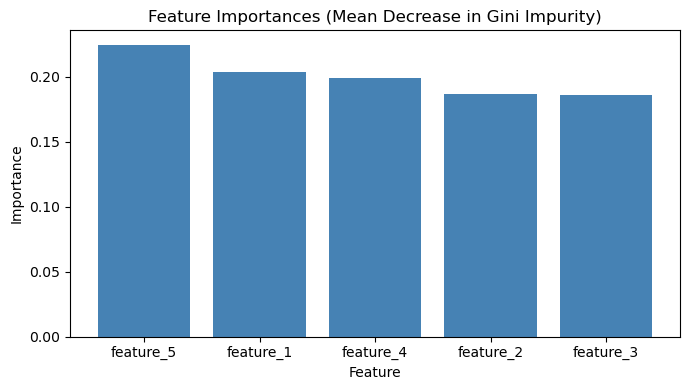


Feature importance ranking:
  1. feature_5     0.2246
  2. feature_1     0.2036
  3. feature_4     0.1992
  4. feature_2     0.1864
  5. feature_3     0.1862


In [9]:
importances = model.feature_importances_
indices     = np.argsort(importances)[::-1]
sorted_features = [feature_cols[i] for i in indices]

plt.figure(figsize=(7, 4))
plt.bar(sorted_features, importances[indices], color='steelblue')
plt.title('Feature Importances (Mean Decrease in Gini Impurity)')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print("\nFeature importance ranking:")
for rank, i in enumerate(indices, 1):
    print(f"  {rank}. {feature_cols[i]:12s}  {importances[i]:.4f}")

## Cross-Validation

In [10]:
# Re-use raw (unscaled) X and y — scaling is applied fresh inside each fold
X_raw = df[feature_cols].values.astype(np.float32)
y_raw = (df['label'] == 'malicious').astype(np.float32).values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracies = []

print("Running 5-fold Stratified Cross-Validation...")
print(f"{'Fold':>5}  {'Accuracy':>10}")
print("-" * 20)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y_raw), 1):
    X_tr,  X_val = X_raw[train_idx], X_raw[val_idx]
    y_tr,  y_val = y_raw[train_idx], y_raw[val_idx]

    fold_scaler = StandardScaler()
    X_tr  = fold_scaler.fit_transform(X_tr).astype(np.float32)
    X_val = fold_scaler.transform(X_val).astype(np.float32)

    fold_model = RandomForestClassifier(
        n_estimators=100, criterion='gini', random_state=42, n_jobs=-1
    )
    fold_model.fit(X_tr, y_tr)

    preds = fold_model.predict(X_val)
    acc   = accuracy_score(y_val, preds)
    cv_accuracies.append(acc)

    print(f"{fold:>5}  {acc:>10.4f}")

print("-" * 20)
print(f"{'Mean':>5}  {np.mean(cv_accuracies):>10.4f}")
print(f"{'Std':>5}  {np.std(cv_accuracies):>10.4f}")
print(f"\nCV Accuracy: {np.mean(cv_accuracies):.4f} ± {np.std(cv_accuracies):.4f}")

Running 5-fold Stratified Cross-Validation...
 Fold    Accuracy
--------------------
    1      0.7725
    2      0.7925
    3      0.7900
    4      0.7800
    5      0.7905
--------------------
 Mean      0.7851
  Std      0.0077

CV Accuracy: 0.7851 ± 0.0077
